# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


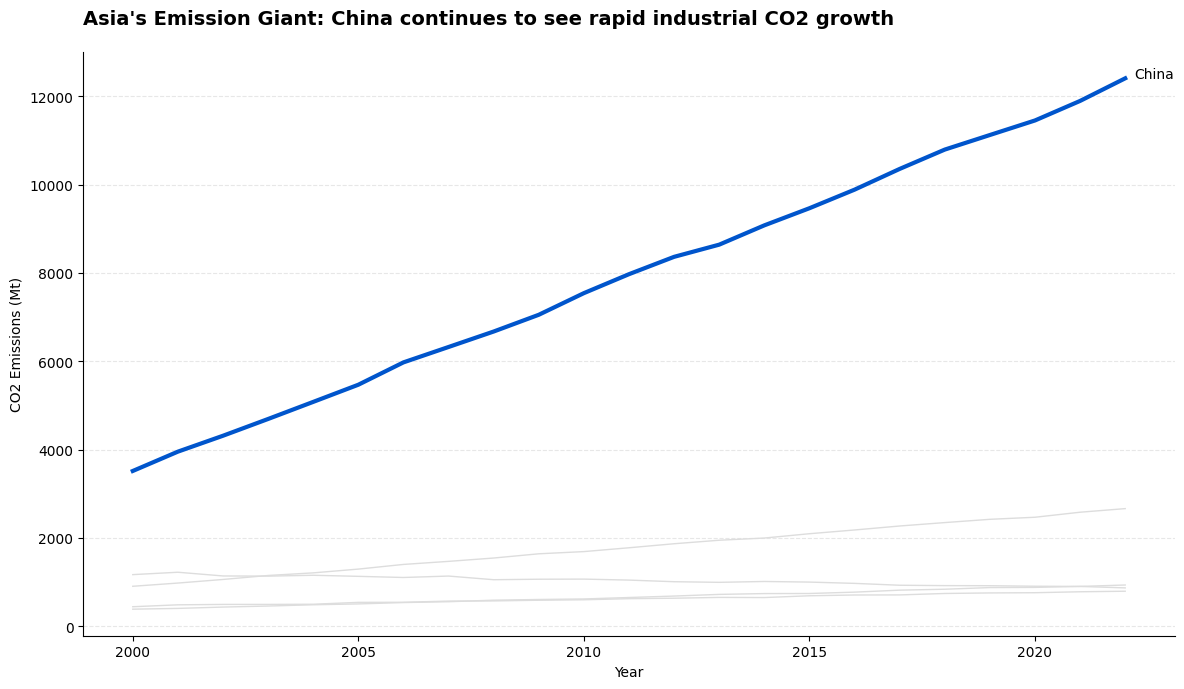

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv(r'C:\Users\SAM\OneDrive\Documents\DV\data-viz-class-material\data\co2_emissions.csv')

# 2. Filter for Asia and identify countries
asia_df = df[df['Region'] == 'Asia']
countries = asia_df['Country'].unique()
highlight_country = 'China'

plt.figure(figsize=(12, 7))

# 3. Loop through countries to apply conditional formatting
for country in countries:
    country_data = asia_df[asia_df['Country'] == country]
    
    # The 'if' starts the block
    if country == highlight_country:
        plt.plot(country_data['Year'], country_data['CO2_Mt'], color='#0055CC', linewidth=3)
        plt.text(country_data['Year'].iloc[-1] + 0.2, country_data['CO2_Mt'].iloc[-1], country)
    
    # The 'else' MUST be perfectly aligned with 'if'
    else:
        plt.plot(country_data['Year'], country_data['CO2_Mt'], color='#DDDDDD', linewidth=1)

# 4. Final Polish and Insight Title
plt.title(f"Asia's Emission Giant: {highlight_country} continues to see rapid industrial CO2 growth", 
          loc='left', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (Mt)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove top/right spines for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64



## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


In [49]:
import plotly.graph_objects as go

# 1. Filter for Asian countries
asia_df = df[df['Region'] == 'Asia']

# 2. Setup the figure
fig = go.Figure()

# Define the country you want to highlight
highlight_country = "China"  # You can change this to any Asian country in your set

# 3. Loop through countries to add lines
countries = asia_df['Country'].unique()

for country in countries:
    country_data = asia_df[asia_df['Country'] == country]
    
    # Determine style based on whether it's the highlighted country
    if country == highlight_country:
        line_color = 'firebrick' # Distinct color
        line_width = 4           # Thicker
        show_label = True
    else:
        line_color = '#DDDDDD'   # Light grey for context
        line_width = 1           # Thinner
        show_label = False

    fig.add_trace(go.Scatter(
        x=country_data['Year'],
        y=country_data['CO2_Mt'],
        mode='lines',
        name=country,
        line=dict(color=line_color, width=line_width),
        hoverinfo='name+x+y',
        showlegend=False # Requirements specify direct labeling, not legend
    ))

    # 4. Add direct label for the highlighted country
    if show_label:
        fig.add_annotation(
            x=country_data['Year'].iloc[-1],
            y=country_data['CO2_Mt'].iloc[-1],
            text=f"  {country}",
            showarrow=False,
            xanchor="left",
            font=dict(color=line_color, size=14)
        )

# 5. Final Layout with Insight Title
fig.update_layout(
    title={
        'text': f"<b>{highlight_country}: Leading CO2 Emissions in Asia</b><br><sup>While most Asian nations maintain lower emission levels, {highlight_country}'s industrial growth shows a sharp upward trend.</sup>",
        'x': 0.05
    },
    xaxis_title="Year",
    yaxis_title="CO2 Emissions (Mt)",
    plot_bgcolor='white',
    margin=dict(r=100) # Space for the direct label
)
# To open the chart in a new browser tab
fig.show(renderer="browser" )

# OR to show it as a static image (requires kaleido package)
# fig.show(renderer="png")



---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


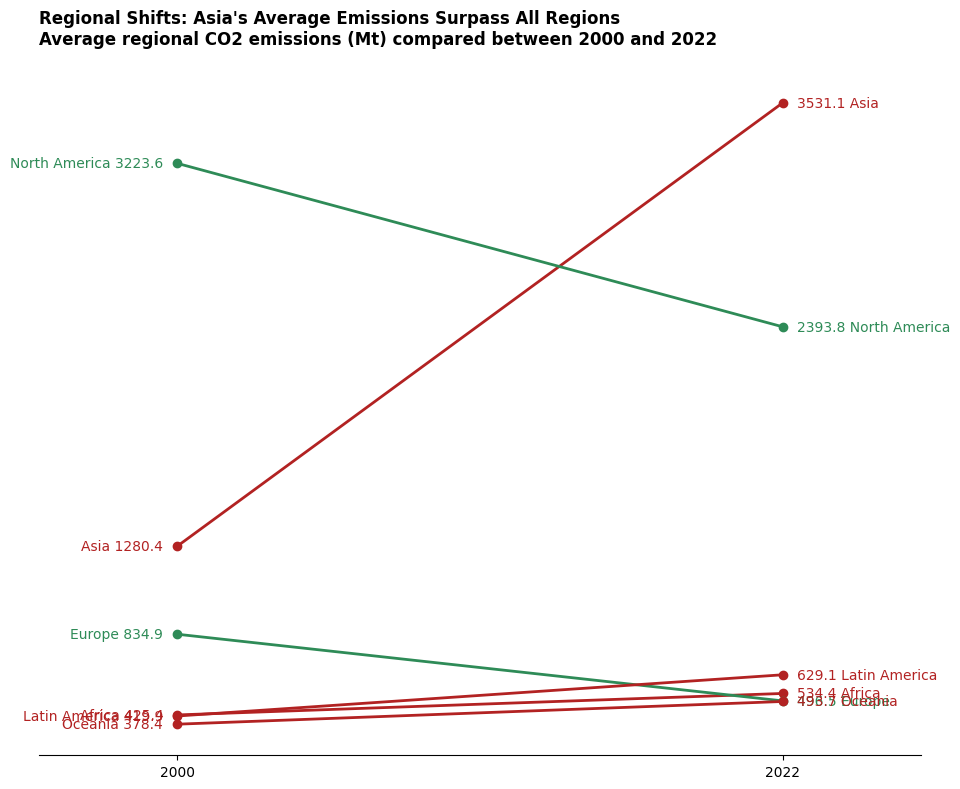

In [47]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('C:\\Users\\SAM\\OneDrive\\Documents\\DV\\data-viz-class-material\\data\\co2_emissions.csv')

# 2. Aggregate: One line per region (average CO2 emissions)
df_agg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()

# 3. Filter for years 2000 and 2022
df_slope = df_agg[df_agg['Year'].isin([2000, 2022])]
df_pivot = df_slope.pivot(index='Region', columns='Year', values='CO2_Mt')

# 4. Setup Plot
plt.figure(figsize=(10, 8))
ax = plt.gca()

for region in df_pivot.index:
    y_start = df_pivot.loc[region, 2000]
    y_end = df_pivot.loc[region, 2022]
    
    # Requirement: Color by increase (red) or decrease (green)
    color = 'firebrick' if y_end > y_start else 'seagreen'
    
    # Plot the line
    plt.plot([2000, 2022], [y_start, y_end], marker='o', color=color, linewidth=2)
    
    # Requirement: Values labelled at both ends
    plt.text(1999.5, y_start, f'{region} {y_start:.1f}', ha='right', va='center', color=color)
    plt.text(2022.5, y_end, f'{y_end:.1f} {region}', ha='left', va='center', color=color)

# 5. Requirement Formatting: No y-axis ticks and clean layout
plt.title("Regional Shifts: Asia's Average Emissions Surpass All Regions\n"
          "Average regional CO2 emissions (Mt) compared between 2000 and 2022", 
          loc='left', fontsize=12, fontweight='bold', pad=20)

plt.xticks([2000, 2022])
plt.yticks([]) # Requirement: No y-axis tick labels
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlim(1995, 2027) # Space for labels
plt.tight_layout()
plt.show()